# $\xi=0.05$

Seeds missing: 0
Pre-Tech → Interm-Tech: Ir 9180/9180, Id 9180/9180, Ig 9180/9180
Interm-Tech → Post-Tech: Ir 702/0, Id 702/702, Ig 702/702
Pre-Tech → Post-Tech: Ir 398/0, Id 398/398, Ig 398/398
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ir_kde_techjump_01.png


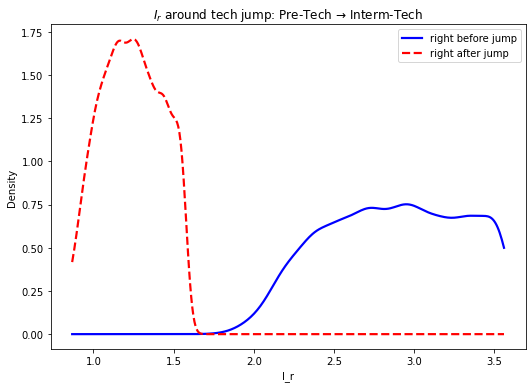

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_techjump_01.png


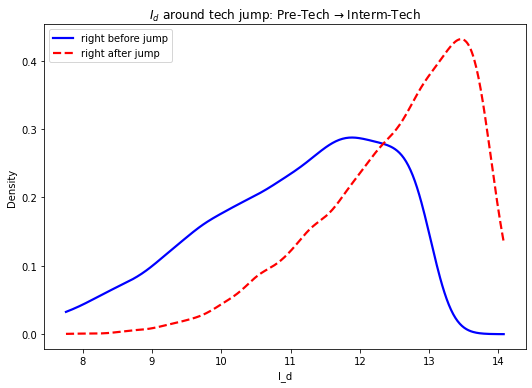

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_techjump_01.png


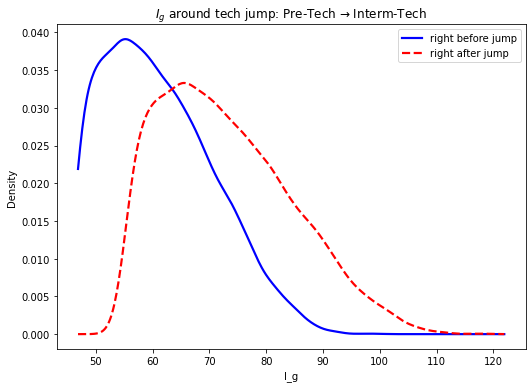

Skipping $I_r$ around tech jump: Interm-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_techjump_12.png


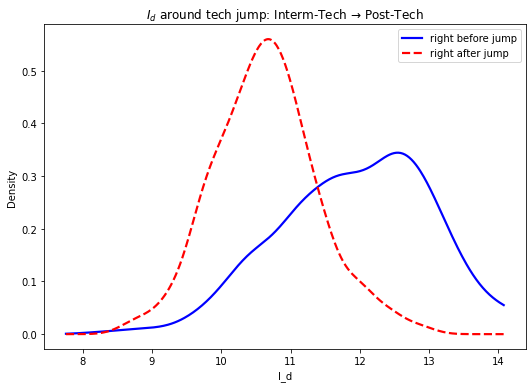

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_techjump_12.png


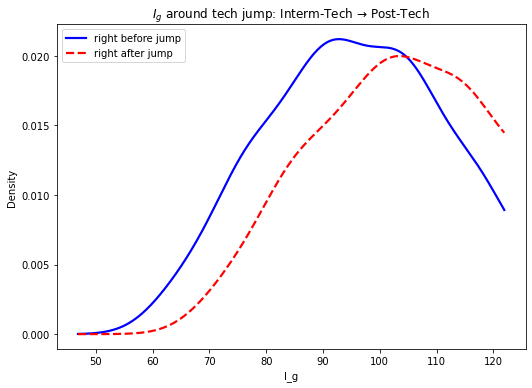

Skipping $I_r$ around tech jump: Pre-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Id_kde_techjump_02.png


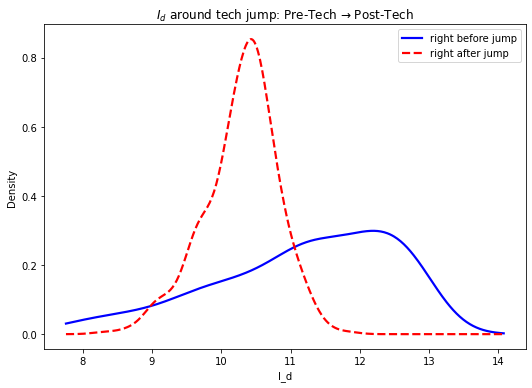

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/Ig_kde_techjump_02.png


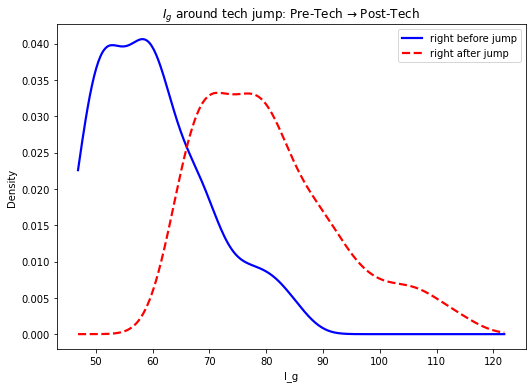

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05"
seed_min, seed_max = 1, 100
save_fig = True

# Consistency with your DAMAGE-jump code:
#   True  => t = (index right AFTER jump), compare t vs t+1   [same as your damage plots]
#   False => compare BEFORE vs AFTER the jump (j vs j+1)
POST_VS_NEXT = True

# Legend labels
LABEL_T  = "right before jump"
LABEL_T1 = "right after jump"

# KDE / x-range config
X_PCTL_LO, X_PCTL_HI = 1, 99
N_X = 400
# ----------------------------

# Three tech jump types (including direct 0->2)
TECH_JUMPS = {
    (0, 1): "Pre-Tech → Interm-Tech",
    (1, 2): "Interm-Tech → Post-Tech",
    (0, 2): "Pre-Tech → Post-Tech",
}


def load_arrays(folder, seed):
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    return T, Ir, Id, Ig


def compute_range(arr, lo_p=X_PCTL_LO, hi_p=X_PCTL_HI):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [lo_p, hi_p])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return float(lo), float(hi)


def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False

    if x_range is None:
        lo, hi = np.percentile(data, [X_PCTL_LO, X_PCTL_HI])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range

    xs = np.linspace(lo, hi, N_X)
    kde = gaussian_kde(data)

    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True


def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]

    if len(x_t) < 2 or len(x_t1) < 2:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))

    ok1 = plot_kde(x_t,  LABEL_T,  "blue", "-",  x_range=x_range)
    ok2 = plot_kde(x_t1, LABEL_T1, "red",  "--", x_range=x_range)

    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()


# ==========================================================
# Collect: for EACH tech jump type, collect Ir/Id/Ig (t vs t1)
# ==========================================================
Ir_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Id_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Ig_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}

missing = 0

for seed in range(seed_min, seed_max + 1):
    try:
        T, Ir, Id, Ig = load_arrays(base_folder, seed)
    except FileNotFoundError:
        missing += 1
        continue

    n_paths, TT = T.shape

    for i in range(n_paths):
        tech_path = T[i].astype(int)

        for (a, b), _name in TECH_JUMPS.items():
            # index j satisfies tech_path[j] = a and tech_path[j+1] = b
            trans = np.where((tech_path[:-1] == a) & (tech_path[1:] == b))[0]
            if trans.size == 0:
                continue

            j = trans[0]

            if POST_VS_NEXT:
                # EXACTLY matches your damage-jump indexing:
                #   t = j+1 (right AFTER jump), t+1 = j+2
                t = j + 1
                if t + 1 >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t], Ir[i, t + 1]
                id_t, id_t1 = Id[i, t], Id[i, t + 1]
                ig_t, ig_t1 = Ig[i, t], Ig[i, t + 1]
            else:
                # pre vs post:
                #   t = j (BEFORE), t1 = j+1 (AFTER)
                t_pre, t_post = j, j + 1
                if t_post >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t_pre], Ir[i, t_post]
                id_t, id_t1 = Id[i, t_pre], Id[i, t_post]
                ig_t, ig_t1 = Ig[i, t_pre], Ig[i, t_post]

            if np.isfinite(ir_t):  Ir_tech[(a, b)]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_tech[(a, b)]["t1"].append(ir_t1)

            if np.isfinite(id_t):  Id_tech[(a, b)]["t"].append(id_t)
            if np.isfinite(id_t1): Id_tech[(a, b)]["t1"].append(id_t1)

            if np.isfinite(ig_t):  Ig_tech[(a, b)]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_tech[(a, b)]["t1"].append(ig_t1)

print(f"Seeds missing: {missing}")
for (a, b), nm in TECH_JUMPS.items():
    print(
        f"{nm}: "
        f"Ir {len(Ir_tech[(a,b)]['t'])}/{len(Ir_tech[(a,b)]['t1'])}, "
        f"Id {len(Id_tech[(a,b)]['t'])}/{len(Id_tech[(a,b)]['t1'])}, "
        f"Ig {len(Ig_tech[(a,b)]['t'])}/{len(Ig_tech[(a,b)]['t1'])}"
    )


# ==========================================================
# Shared x-ranges PER VARIABLE across ALL jump types
# (so each variable is comparable across jump types)
# ==========================================================
Ir_all = np.array(
    Ir_tech[(0, 1)]["t"] + Ir_tech[(0, 1)]["t1"] +
    Ir_tech[(1, 2)]["t"] + Ir_tech[(1, 2)]["t1"] +
    Ir_tech[(0, 2)]["t"] + Ir_tech[(0, 2)]["t1"],
    dtype=float
)
Id_all = np.array(
    Id_tech[(0, 1)]["t"] + Id_tech[(0, 1)]["t1"] +
    Id_tech[(1, 2)]["t"] + Id_tech[(1, 2)]["t1"] +
    Id_tech[(0, 2)]["t"] + Id_tech[(0, 2)]["t1"],
    dtype=float
)
Ig_all = np.array(
    Ig_tech[(0, 1)]["t"] + Ig_tech[(0, 1)]["t1"] +
    Ig_tech[(1, 2)]["t"] + Ig_tech[(1, 2)]["t1"] +
    Ig_tech[(0, 2)]["t"] + Ig_tech[(0, 2)]["t1"],
    dtype=float
)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)


# ==========================================================
# PLOT: for each tech jump type, plot ALL controls (Ir, Id, Ig)
# comparing t vs t1 around THAT jump.
# Total figures = 3 jump types × 3 controls = 9.
# ==========================================================
for (a, b), jump_name in TECH_JUMPS.items():
    plot_density(
        Ir_tech[(a, b)]["t"], Ir_tech[(a, b)]["t1"],
        xlabel="I_r",
        title=rf"$I_r$ around tech jump: {jump_name}",
        filename=f"Ir_kde_techjump_{a}{b}.png",
        x_range=Ir_range
    )

    plot_density(
        Id_tech[(a, b)]["t"], Id_tech[(a, b)]["t1"],
        xlabel="I_d",
        title=rf"$I_d$ around tech jump: {jump_name}",
        filename=f"Id_kde_techjump_{a}{b}.png",
        x_range=Id_range
    )

    plot_density(
        Ig_tech[(a, b)]["t"], Ig_tech[(a, b)]["t1"],
        xlabel="I_g",
        title=rf"$I_g$ around tech jump: {jump_name}",
        filename=f"Ig_kde_techjump_{a}{b}.png",
        x_range=Ig_range
    )


# $\xi=0.1$

Seeds missing: 0
Pre-Tech → Interm-Tech: Ir 9223/9223, Id 9223/9223, Ig 9223/9223
Interm-Tech → Post-Tech: Ir 678/0, Id 678/678, Ig 678/678
Pre-Tech → Post-Tech: Ir 358/0, Id 358/358, Ig 358/358
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ir_kde_techjump_01.png


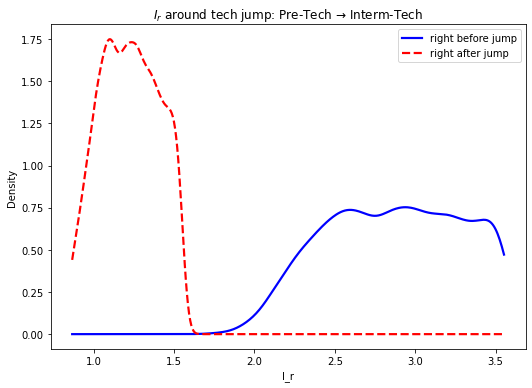

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_techjump_01.png


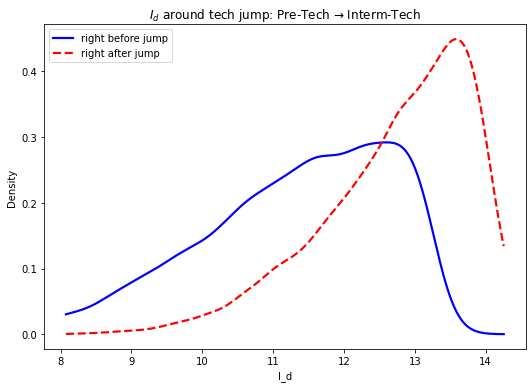

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_techjump_01.png


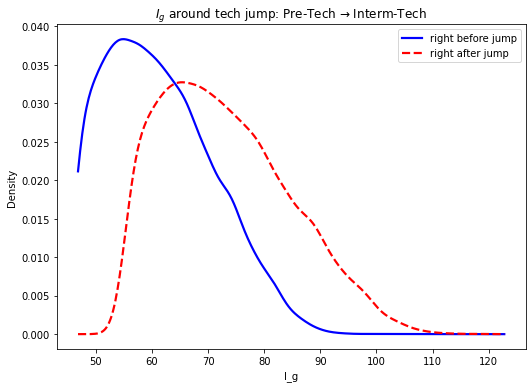

Skipping $I_r$ around tech jump: Interm-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_techjump_12.png


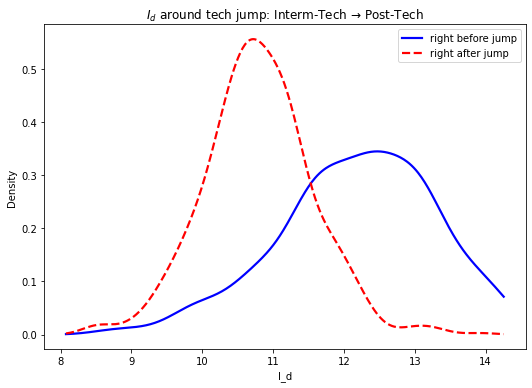

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_techjump_12.png


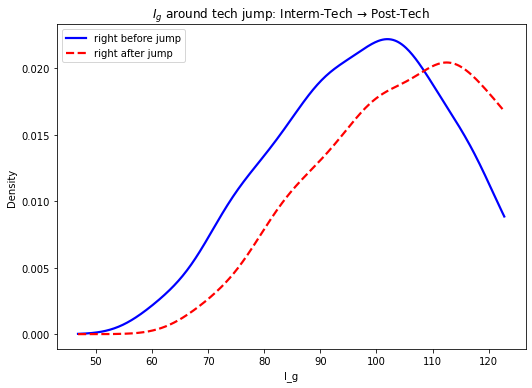

Skipping $I_r$ around tech jump: Pre-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Id_kde_techjump_02.png


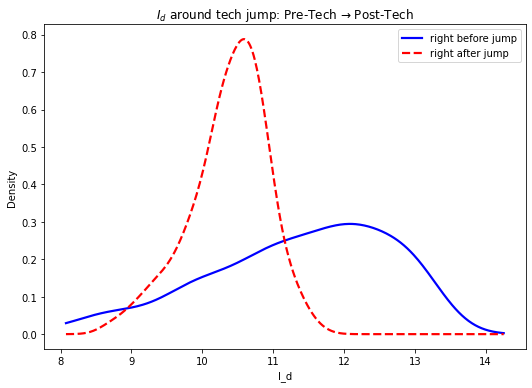

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/Ig_kde_techjump_02.png


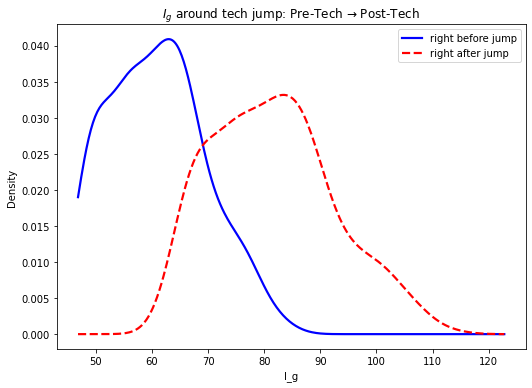

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1"
seed_min, seed_max = 1, 100
save_fig = True

# Consistency with your DAMAGE-jump code:
#   True  => t = (index right AFTER jump), compare t vs t+1   [same as your damage plots]
#   False => compare BEFORE vs AFTER the jump (j vs j+1)
POST_VS_NEXT = True

# Legend labels
LABEL_T  = "right before jump"
LABEL_T1 = "right after jump"

# KDE / x-range config
X_PCTL_LO, X_PCTL_HI = 1, 99
N_X = 400
# ----------------------------

# Three tech jump types (including direct 0->2)
TECH_JUMPS = {
    (0, 1): "Pre-Tech → Interm-Tech",
    (1, 2): "Interm-Tech → Post-Tech",
    (0, 2): "Pre-Tech → Post-Tech",
}


def load_arrays(folder, seed):
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    return T, Ir, Id, Ig


def compute_range(arr, lo_p=X_PCTL_LO, hi_p=X_PCTL_HI):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [lo_p, hi_p])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return float(lo), float(hi)


def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False

    if x_range is None:
        lo, hi = np.percentile(data, [X_PCTL_LO, X_PCTL_HI])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range

    xs = np.linspace(lo, hi, N_X)
    kde = gaussian_kde(data)

    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True


def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]

    if len(x_t) < 2 or len(x_t1) < 2:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))

    ok1 = plot_kde(x_t,  LABEL_T,  "blue", "-",  x_range=x_range)
    ok2 = plot_kde(x_t1, LABEL_T1, "red",  "--", x_range=x_range)

    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()


# ==========================================================
# Collect: for EACH tech jump type, collect Ir/Id/Ig (t vs t1)
# ==========================================================
Ir_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Id_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Ig_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}

missing = 0

for seed in range(seed_min, seed_max + 1):
    try:
        T, Ir, Id, Ig = load_arrays(base_folder, seed)
    except FileNotFoundError:
        missing += 1
        continue

    n_paths, TT = T.shape

    for i in range(n_paths):
        tech_path = T[i].astype(int)

        for (a, b), _name in TECH_JUMPS.items():
            # index j satisfies tech_path[j] = a and tech_path[j+1] = b
            trans = np.where((tech_path[:-1] == a) & (tech_path[1:] == b))[0]
            if trans.size == 0:
                continue

            j = trans[0]

            if POST_VS_NEXT:
                # EXACTLY matches your damage-jump indexing:
                #   t = j+1 (right AFTER jump), t+1 = j+2
                t = j + 1
                if t + 1 >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t], Ir[i, t + 1]
                id_t, id_t1 = Id[i, t], Id[i, t + 1]
                ig_t, ig_t1 = Ig[i, t], Ig[i, t + 1]
            else:
                # pre vs post:
                #   t = j (BEFORE), t1 = j+1 (AFTER)
                t_pre, t_post = j, j + 1
                if t_post >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t_pre], Ir[i, t_post]
                id_t, id_t1 = Id[i, t_pre], Id[i, t_post]
                ig_t, ig_t1 = Ig[i, t_pre], Ig[i, t_post]

            if np.isfinite(ir_t):  Ir_tech[(a, b)]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_tech[(a, b)]["t1"].append(ir_t1)

            if np.isfinite(id_t):  Id_tech[(a, b)]["t"].append(id_t)
            if np.isfinite(id_t1): Id_tech[(a, b)]["t1"].append(id_t1)

            if np.isfinite(ig_t):  Ig_tech[(a, b)]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_tech[(a, b)]["t1"].append(ig_t1)

print(f"Seeds missing: {missing}")
for (a, b), nm in TECH_JUMPS.items():
    print(
        f"{nm}: "
        f"Ir {len(Ir_tech[(a,b)]['t'])}/{len(Ir_tech[(a,b)]['t1'])}, "
        f"Id {len(Id_tech[(a,b)]['t'])}/{len(Id_tech[(a,b)]['t1'])}, "
        f"Ig {len(Ig_tech[(a,b)]['t'])}/{len(Ig_tech[(a,b)]['t1'])}"
    )


# ==========================================================
# Shared x-ranges PER VARIABLE across ALL jump types
# (so each variable is comparable across jump types)
# ==========================================================
Ir_all = np.array(
    Ir_tech[(0, 1)]["t"] + Ir_tech[(0, 1)]["t1"] +
    Ir_tech[(1, 2)]["t"] + Ir_tech[(1, 2)]["t1"] +
    Ir_tech[(0, 2)]["t"] + Ir_tech[(0, 2)]["t1"],
    dtype=float
)
Id_all = np.array(
    Id_tech[(0, 1)]["t"] + Id_tech[(0, 1)]["t1"] +
    Id_tech[(1, 2)]["t"] + Id_tech[(1, 2)]["t1"] +
    Id_tech[(0, 2)]["t"] + Id_tech[(0, 2)]["t1"],
    dtype=float
)
Ig_all = np.array(
    Ig_tech[(0, 1)]["t"] + Ig_tech[(0, 1)]["t1"] +
    Ig_tech[(1, 2)]["t"] + Ig_tech[(1, 2)]["t1"] +
    Ig_tech[(0, 2)]["t"] + Ig_tech[(0, 2)]["t1"],
    dtype=float
)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)


# ==========================================================
# PLOT: for each tech jump type, plot ALL controls (Ir, Id, Ig)
# comparing t vs t1 around THAT jump.
# Total figures = 3 jump types × 3 controls = 9.
# ==========================================================
for (a, b), jump_name in TECH_JUMPS.items():
    plot_density(
        Ir_tech[(a, b)]["t"], Ir_tech[(a, b)]["t1"],
        xlabel="I_r",
        title=rf"$I_r$ around tech jump: {jump_name}",
        filename=f"Ir_kde_techjump_{a}{b}.png",
        x_range=Ir_range
    )

    plot_density(
        Id_tech[(a, b)]["t"], Id_tech[(a, b)]["t1"],
        xlabel="I_d",
        title=rf"$I_d$ around tech jump: {jump_name}",
        filename=f"Id_kde_techjump_{a}{b}.png",
        x_range=Id_range
    )

    plot_density(
        Ig_tech[(a, b)]["t"], Ig_tech[(a, b)]["t1"],
        xlabel="I_g",
        title=rf"$I_g$ around tech jump: {jump_name}",
        filename=f"Ig_kde_techjump_{a}{b}.png",
        x_range=Ig_range
    )


# $\xi = 0.3$



Seeds missing: 0
Pre-Tech → Interm-Tech: Ir 9161/9161, Id 9161/9161, Ig 9161/9161
Interm-Tech → Post-Tech: Ir 720/0, Id 720/720, Ig 720/720
Pre-Tech → Post-Tech: Ir 382/0, Id 382/382, Ig 382/382
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ir_kde_techjump_01.png


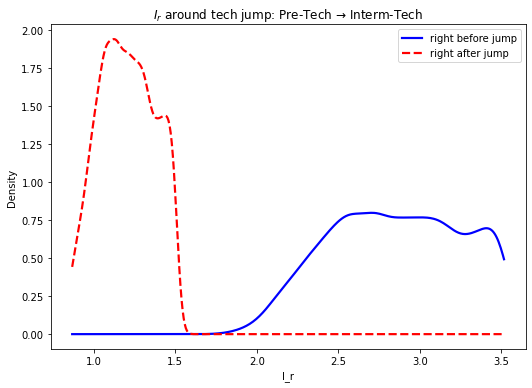

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_techjump_01.png


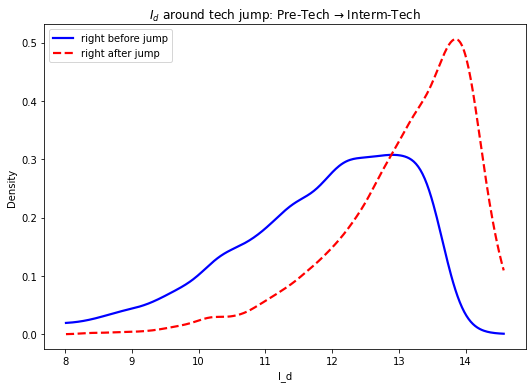

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_techjump_01.png


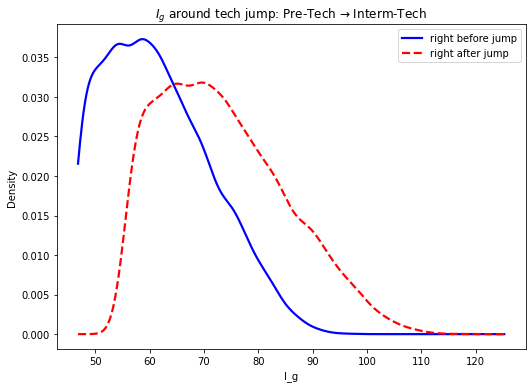

Skipping $I_r$ around tech jump: Interm-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_techjump_12.png


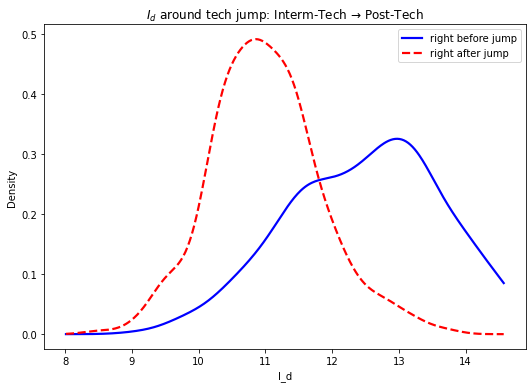

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_techjump_12.png


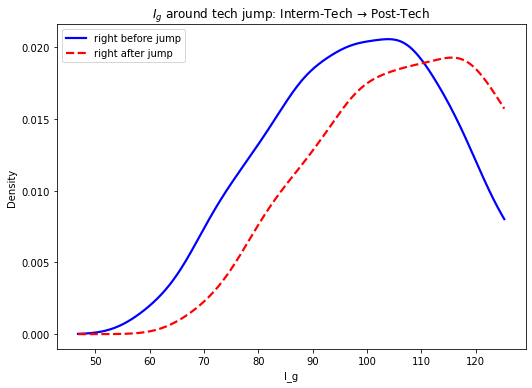

Skipping $I_r$ around tech jump: Pre-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Id_kde_techjump_02.png


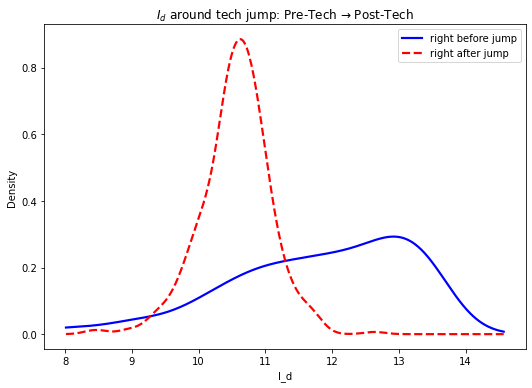

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/Ig_kde_techjump_02.png


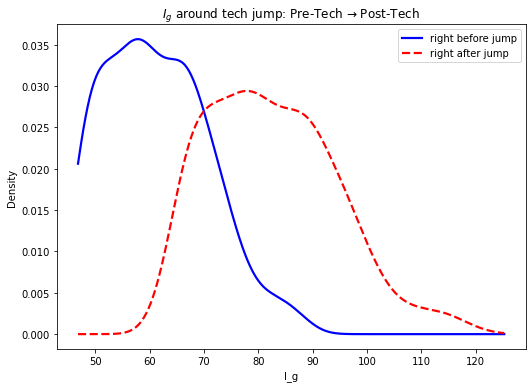

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3"
seed_min, seed_max = 1, 100
save_fig = True

# Consistency with your DAMAGE-jump code:
#   True  => t = (index right AFTER jump), compare t vs t+1   [same as your damage plots]
#   False => compare BEFORE vs AFTER the jump (j vs j+1)
POST_VS_NEXT = True

# Legend labels
LABEL_T  = "right before jump"
LABEL_T1 = "right after jump"

# KDE / x-range config
X_PCTL_LO, X_PCTL_HI = 1, 99
N_X = 400
# ----------------------------

# Three tech jump types (including direct 0->2)
TECH_JUMPS = {
    (0, 1): "Pre-Tech → Interm-Tech",
    (1, 2): "Interm-Tech → Post-Tech",
    (0, 2): "Pre-Tech → Post-Tech",
}


def load_arrays(folder, seed):
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    return T, Ir, Id, Ig


def compute_range(arr, lo_p=X_PCTL_LO, hi_p=X_PCTL_HI):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [lo_p, hi_p])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return float(lo), float(hi)


def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False

    if x_range is None:
        lo, hi = np.percentile(data, [X_PCTL_LO, X_PCTL_HI])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range

    xs = np.linspace(lo, hi, N_X)
    kde = gaussian_kde(data)

    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True


def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]

    if len(x_t) < 2 or len(x_t1) < 2:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))

    ok1 = plot_kde(x_t,  LABEL_T,  "blue", "-",  x_range=x_range)
    ok2 = plot_kde(x_t1, LABEL_T1, "red",  "--", x_range=x_range)

    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()


# ==========================================================
# Collect: for EACH tech jump type, collect Ir/Id/Ig (t vs t1)
# ==========================================================
Ir_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Id_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Ig_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}

missing = 0

for seed in range(seed_min, seed_max + 1):
    try:
        T, Ir, Id, Ig = load_arrays(base_folder, seed)
    except FileNotFoundError:
        missing += 1
        continue

    n_paths, TT = T.shape

    for i in range(n_paths):
        tech_path = T[i].astype(int)

        for (a, b), _name in TECH_JUMPS.items():
            # index j satisfies tech_path[j] = a and tech_path[j+1] = b
            trans = np.where((tech_path[:-1] == a) & (tech_path[1:] == b))[0]
            if trans.size == 0:
                continue

            j = trans[0]

            if POST_VS_NEXT:
                # EXACTLY matches your damage-jump indexing:
                #   t = j+1 (right AFTER jump), t+1 = j+2
                t = j + 1
                if t + 1 >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t], Ir[i, t + 1]
                id_t, id_t1 = Id[i, t], Id[i, t + 1]
                ig_t, ig_t1 = Ig[i, t], Ig[i, t + 1]
            else:
                # pre vs post:
                #   t = j (BEFORE), t1 = j+1 (AFTER)
                t_pre, t_post = j, j + 1
                if t_post >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t_pre], Ir[i, t_post]
                id_t, id_t1 = Id[i, t_pre], Id[i, t_post]
                ig_t, ig_t1 = Ig[i, t_pre], Ig[i, t_post]

            if np.isfinite(ir_t):  Ir_tech[(a, b)]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_tech[(a, b)]["t1"].append(ir_t1)

            if np.isfinite(id_t):  Id_tech[(a, b)]["t"].append(id_t)
            if np.isfinite(id_t1): Id_tech[(a, b)]["t1"].append(id_t1)

            if np.isfinite(ig_t):  Ig_tech[(a, b)]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_tech[(a, b)]["t1"].append(ig_t1)

print(f"Seeds missing: {missing}")
for (a, b), nm in TECH_JUMPS.items():
    print(
        f"{nm}: "
        f"Ir {len(Ir_tech[(a,b)]['t'])}/{len(Ir_tech[(a,b)]['t1'])}, "
        f"Id {len(Id_tech[(a,b)]['t'])}/{len(Id_tech[(a,b)]['t1'])}, "
        f"Ig {len(Ig_tech[(a,b)]['t'])}/{len(Ig_tech[(a,b)]['t1'])}"
    )


# ==========================================================
# Shared x-ranges PER VARIABLE across ALL jump types
# (so each variable is comparable across jump types)
# ==========================================================
Ir_all = np.array(
    Ir_tech[(0, 1)]["t"] + Ir_tech[(0, 1)]["t1"] +
    Ir_tech[(1, 2)]["t"] + Ir_tech[(1, 2)]["t1"] +
    Ir_tech[(0, 2)]["t"] + Ir_tech[(0, 2)]["t1"],
    dtype=float
)
Id_all = np.array(
    Id_tech[(0, 1)]["t"] + Id_tech[(0, 1)]["t1"] +
    Id_tech[(1, 2)]["t"] + Id_tech[(1, 2)]["t1"] +
    Id_tech[(0, 2)]["t"] + Id_tech[(0, 2)]["t1"],
    dtype=float
)
Ig_all = np.array(
    Ig_tech[(0, 1)]["t"] + Ig_tech[(0, 1)]["t1"] +
    Ig_tech[(1, 2)]["t"] + Ig_tech[(1, 2)]["t1"] +
    Ig_tech[(0, 2)]["t"] + Ig_tech[(0, 2)]["t1"],
    dtype=float
)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)


# ==========================================================
# PLOT: for each tech jump type, plot ALL controls (Ir, Id, Ig)
# comparing t vs t1 around THAT jump.
# Total figures = 3 jump types × 3 controls = 9.
# ==========================================================
for (a, b), jump_name in TECH_JUMPS.items():
    plot_density(
        Ir_tech[(a, b)]["t"], Ir_tech[(a, b)]["t1"],
        xlabel="I_r",
        title=rf"$I_r$ around tech jump: {jump_name}",
        filename=f"Ir_kde_techjump_{a}{b}.png",
        x_range=Ir_range
    )

    plot_density(
        Id_tech[(a, b)]["t"], Id_tech[(a, b)]["t1"],
        xlabel="I_d",
        title=rf"$I_d$ around tech jump: {jump_name}",
        filename=f"Id_kde_techjump_{a}{b}.png",
        x_range=Id_range
    )

    plot_density(
        Ig_tech[(a, b)]["t"], Ig_tech[(a, b)]["t1"],
        xlabel="I_g",
        title=rf"$I_g$ around tech jump: {jump_name}",
        filename=f"Ig_kde_techjump_{a}{b}.png",
        x_range=Ig_range
    )


# $\xi = \infty$

Seeds missing: 0
Pre-Tech → Interm-Tech: Ir 9205/9205, Id 9205/9205, Ig 9205/9205
Interm-Tech → Post-Tech: Ir 680/0, Id 680/680, Ig 680/680
Pre-Tech → Post-Tech: Ir 342/0, Id 342/342, Ig 342/342
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ir_kde_techjump_01.png


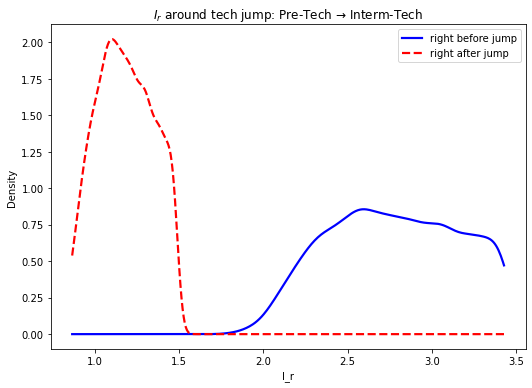

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_techjump_01.png


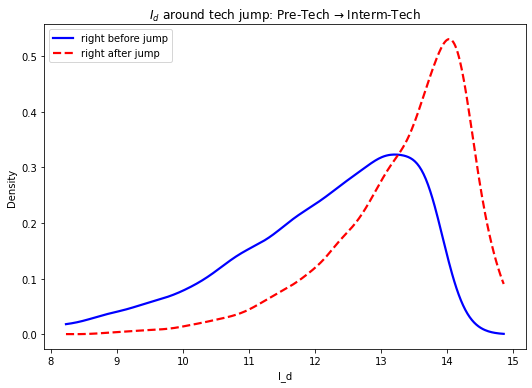

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_techjump_01.png


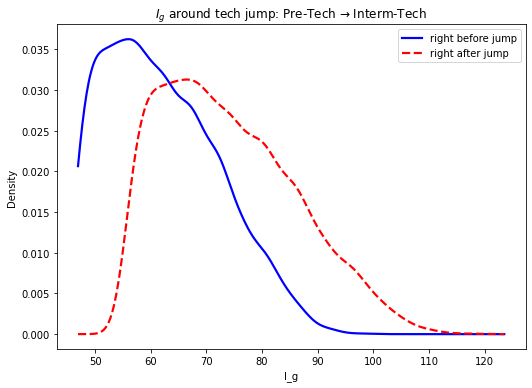

Skipping $I_r$ around tech jump: Interm-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_techjump_12.png


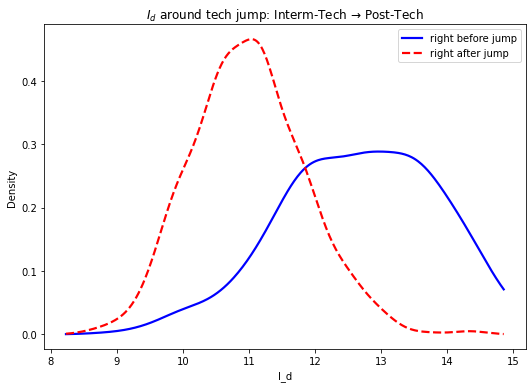

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_techjump_12.png


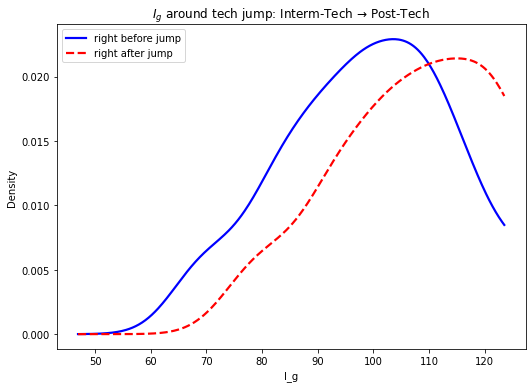

Skipping $I_r$ around tech jump: Pre-Tech → Post-Tech — insufficient data.
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Id_kde_techjump_02.png


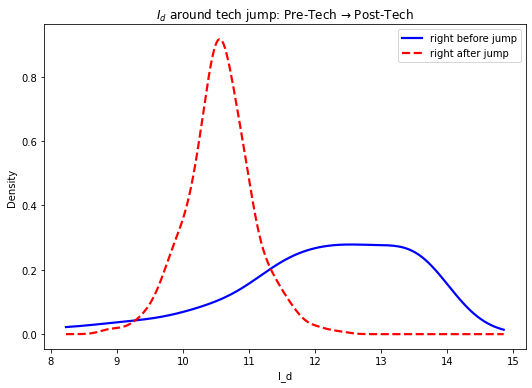

Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/Ig_kde_techjump_02.png


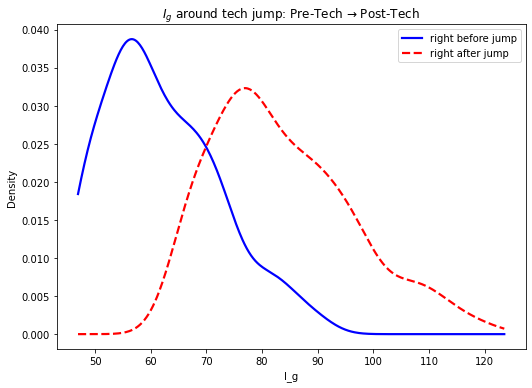

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4"
seed_min, seed_max = 1, 100
save_fig = True

# Consistency with your DAMAGE-jump code:
#   True  => t = (index right AFTER jump), compare t vs t+1   [same as your damage plots]
#   False => compare BEFORE vs AFTER the jump (j vs j+1)
POST_VS_NEXT = True

# Legend labels
LABEL_T  = "right before jump"
LABEL_T1 = "right after jump"

# KDE / x-range config
X_PCTL_LO, X_PCTL_HI = 1, 99
N_X = 400
# ----------------------------

# Three tech jump types (including direct 0->2)
TECH_JUMPS = {
    (0, 1): "Pre-Tech → Interm-Tech",
    (1, 2): "Interm-Tech → Post-Tech",
    (0, 2): "Pre-Tech → Post-Tech",
}


def load_arrays(folder, seed):
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    return T, Ir, Id, Ig


def compute_range(arr, lo_p=X_PCTL_LO, hi_p=X_PCTL_HI):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return None
    lo, hi = np.percentile(arr, [lo_p, hi_p])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return float(lo), float(hi)


def plot_kde(data, label, color=None, linestyle="-", x_range=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 2:
        return False
    if np.allclose(np.std(data), 0):
        return False

    if x_range is None:
        lo, hi = np.percentile(data, [X_PCTL_LO, X_PCTL_HI])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return False
    else:
        lo, hi = x_range

    xs = np.linspace(lo, hi, N_X)
    kde = gaussian_kde(data)

    if color is None:
        plt.plot(xs, kde(xs), lw=2.2, linestyle=linestyle, label=label)
    else:
        plt.plot(xs, kde(xs), color=color, lw=2.2, linestyle=linestyle, label=label)
    return True


def plot_density(x_t, x_t1, xlabel, title, filename, x_range=None):
    x_t  = [v for v in x_t  if np.isfinite(v)]
    x_t1 = [v for v in x_t1 if np.isfinite(v)]

    if len(x_t) < 2 or len(x_t1) < 2:
        print(f"Skipping {title} — insufficient data.")
        return

    plt.figure(figsize=(7.5, 5.5))

    ok1 = plot_kde(x_t,  LABEL_T,  "blue", "-",  x_range=x_range)
    ok2 = plot_kde(x_t1, LABEL_T1, "red",  "--", x_range=x_range)

    if not (ok1 and ok2):
        print(f"Skipping {title} — insufficient variance.")
        plt.close()
        return

    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_fig:
        out = os.path.join(base_folder, filename)
        plt.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()


# ==========================================================
# Collect: for EACH tech jump type, collect Ir/Id/Ig (t vs t1)
# ==========================================================
Ir_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Id_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}
Ig_tech = {k: {"t": [], "t1": []} for k in TECH_JUMPS}

missing = 0

for seed in range(seed_min, seed_max + 1):
    try:
        T, Ir, Id, Ig = load_arrays(base_folder, seed)
    except FileNotFoundError:
        missing += 1
        continue

    n_paths, TT = T.shape

    for i in range(n_paths):
        tech_path = T[i].astype(int)

        for (a, b), _name in TECH_JUMPS.items():
            # index j satisfies tech_path[j] = a and tech_path[j+1] = b
            trans = np.where((tech_path[:-1] == a) & (tech_path[1:] == b))[0]
            if trans.size == 0:
                continue

            j = trans[0]

            if POST_VS_NEXT:
                # EXACTLY matches your damage-jump indexing:
                #   t = j+1 (right AFTER jump), t+1 = j+2
                t = j + 1
                if t + 1 >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t], Ir[i, t + 1]
                id_t, id_t1 = Id[i, t], Id[i, t + 1]
                ig_t, ig_t1 = Ig[i, t], Ig[i, t + 1]
            else:
                # pre vs post:
                #   t = j (BEFORE), t1 = j+1 (AFTER)
                t_pre, t_post = j, j + 1
                if t_post >= TT:
                    continue
                ir_t, ir_t1 = Ir[i, t_pre], Ir[i, t_post]
                id_t, id_t1 = Id[i, t_pre], Id[i, t_post]
                ig_t, ig_t1 = Ig[i, t_pre], Ig[i, t_post]

            if np.isfinite(ir_t):  Ir_tech[(a, b)]["t"].append(ir_t)
            if np.isfinite(ir_t1): Ir_tech[(a, b)]["t1"].append(ir_t1)

            if np.isfinite(id_t):  Id_tech[(a, b)]["t"].append(id_t)
            if np.isfinite(id_t1): Id_tech[(a, b)]["t1"].append(id_t1)

            if np.isfinite(ig_t):  Ig_tech[(a, b)]["t"].append(ig_t)
            if np.isfinite(ig_t1): Ig_tech[(a, b)]["t1"].append(ig_t1)

print(f"Seeds missing: {missing}")
for (a, b), nm in TECH_JUMPS.items():
    print(
        f"{nm}: "
        f"Ir {len(Ir_tech[(a,b)]['t'])}/{len(Ir_tech[(a,b)]['t1'])}, "
        f"Id {len(Id_tech[(a,b)]['t'])}/{len(Id_tech[(a,b)]['t1'])}, "
        f"Ig {len(Ig_tech[(a,b)]['t'])}/{len(Ig_tech[(a,b)]['t1'])}"
    )


# ==========================================================
# Shared x-ranges PER VARIABLE across ALL jump types
# (so each variable is comparable across jump types)
# ==========================================================
Ir_all = np.array(
    Ir_tech[(0, 1)]["t"] + Ir_tech[(0, 1)]["t1"] +
    Ir_tech[(1, 2)]["t"] + Ir_tech[(1, 2)]["t1"] +
    Ir_tech[(0, 2)]["t"] + Ir_tech[(0, 2)]["t1"],
    dtype=float
)
Id_all = np.array(
    Id_tech[(0, 1)]["t"] + Id_tech[(0, 1)]["t1"] +
    Id_tech[(1, 2)]["t"] + Id_tech[(1, 2)]["t1"] +
    Id_tech[(0, 2)]["t"] + Id_tech[(0, 2)]["t1"],
    dtype=float
)
Ig_all = np.array(
    Ig_tech[(0, 1)]["t"] + Ig_tech[(0, 1)]["t1"] +
    Ig_tech[(1, 2)]["t"] + Ig_tech[(1, 2)]["t1"] +
    Ig_tech[(0, 2)]["t"] + Ig_tech[(0, 2)]["t1"],
    dtype=float
)

Ir_range = compute_range(Ir_all)
Id_range = compute_range(Id_all)
Ig_range = compute_range(Ig_all)


# ==========================================================
# PLOT: for each tech jump type, plot ALL controls (Ir, Id, Ig)
# comparing t vs t1 around THAT jump.
# Total figures = 3 jump types × 3 controls = 9.
# ==========================================================
for (a, b), jump_name in TECH_JUMPS.items():
    plot_density(
        Ir_tech[(a, b)]["t"], Ir_tech[(a, b)]["t1"],
        xlabel="I_r",
        title=rf"$I_r$ around tech jump: {jump_name}",
        filename=f"Ir_kde_techjump_{a}{b}.png",
        x_range=Ir_range
    )

    plot_density(
        Id_tech[(a, b)]["t"], Id_tech[(a, b)]["t1"],
        xlabel="I_d",
        title=rf"$I_d$ around tech jump: {jump_name}",
        filename=f"Id_kde_techjump_{a}{b}.png",
        x_range=Id_range
    )

    plot_density(
        Ig_tech[(a, b)]["t"], Ig_tech[(a, b)]["t1"],
        xlabel="I_g",
        title=rf"$I_g$ around tech jump: {jump_name}",
        filename=f"Ig_kde_techjump_{a}{b}.png",
        x_range=Ig_range
    )
